# **MINIST Handwritten Classification**

## 1. Import Libraries

In [2]:
import torch
from torch import nn

import torchvision
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt
import pandas as pd

## 2. Getting dataset

In [5]:
train_df = pd.read_csv("../Dataset/train.csv")

In [6]:
train_df.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from torch.utils.data import Dataset

class DataFrameDataset(Dataset):
  def __init__(self , df , features_cols , label_cols):
    self.X = torch.tensor(
        df[features_cols].values , dtype = torch.float32
    )
    self.y = torch.tensor(
        df[label_cols].values , dtype = torch.long
    )

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    image = self.X[idx].reshape(1 , 28 , 28)
    label = self.y[idx]
    return image , label

In [ ]:
cols_list = train_df.columns.tolist()

X_df = train_df[cols_list[1:]]
y_df = train_df[cols_list[0]]

X_df = X_df / 255.0

train_df = pd.concat([y_df , X_df] , axis = 1)

In [ ]:
train_data = DataFrameDataset(train_df , cols_list[1:] , cols_list[0])

In [ ]:
len(train_data)

42000

In [ ]:
# See the first training example
image , label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [ ]:
print(f"Image shape : {image.shape} -> [color_channels , height , width]")
print(f"Image label : {label.shape}")

Image shape : torch.Size([1, 28, 28]) -> [color_channels , height , width]
Image label : torch.Size([])


Visualize the data

Image shape : torch.Size([1, 28, 28])


Text(0.5, 1.0, 'tensor(5)')

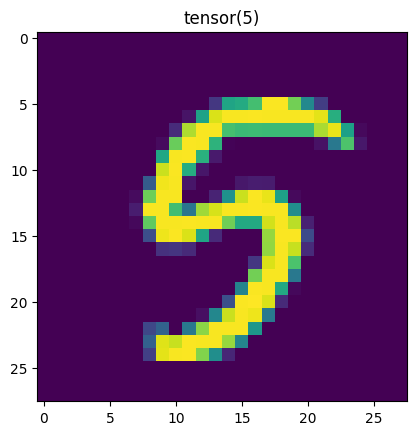

In [ ]:
image , label = train_data[8]
print(f"Image shape : {image.shape}")

plt.imshow(image.squeeze())
plt.title(label)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

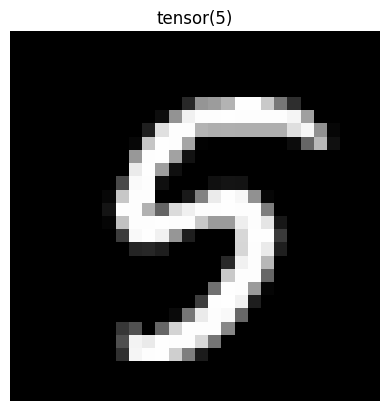

In [ ]:
plt.imshow(image.squeeze() , cmap = "gray")
plt.title(label)
plt.axis(False)

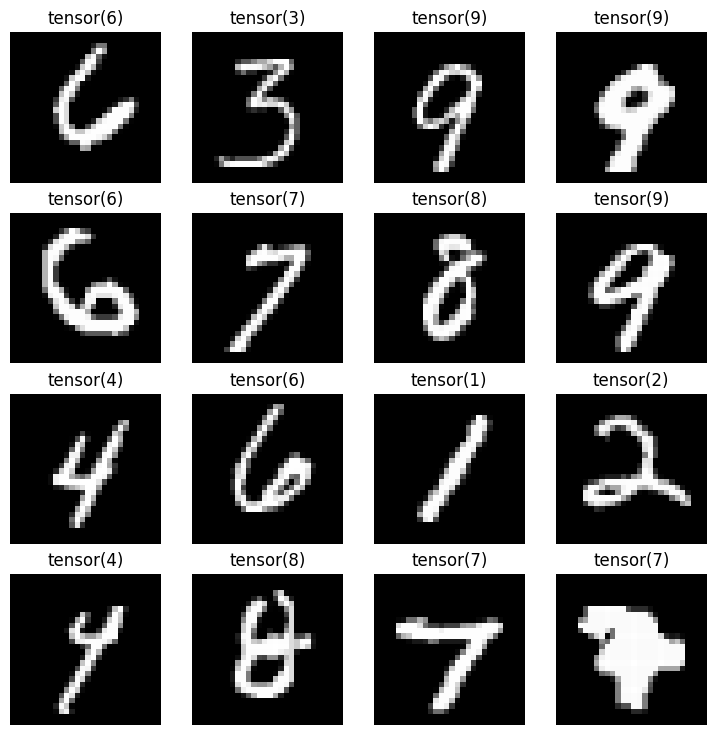

In [ ]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize = (9 , 9))
rows , cols = 4 , 4
for i in range(1 , rows*cols + 1):
  random_idx = torch.randint(0 , len(train_data) , size = [1]).item()
  img , label = train_data[random_idx]
  fig.add_subplot(rows , cols , i)
  plt.imshow(img.squeeze() , cmap = "gray")
  plt.title(label)
  plt.axis(False)

## 3. Prepare DataLoader

In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(train_data))
test_size = len(train_data) - train_size

train_dataset , test_dataset = random_split(train_data ,
                                            [train_size , test_size])

print(len(train_dataset))
print(len(test_dataset))

33600
8400


In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_dataset , batch_size = BATCH_SIZE , shuffle = True
)

test_dataloader = DataLoader(
    test_dataset , batch_size = BATCH_SIZE , shuffle = False
)

train_dataloader , test_dataloader


(<torch.utils.data.dataloader.DataLoader at 0x7bf6488d2d80>,
 <torch.utils.data.dataloader.DataLoader at 0x7bf648f9c770>)

In [ ]:
# Let's check out what we've created
print(f"DataLoaders : {train_dataloader , test_dataloader}")
print(f"Length of train_dataloader : {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader : {len(test_dataloader)} batches of {BATCH_SIZE}...")



DataLoaders : (<torch.utils.data.dataloader.DataLoader object at 0x7bf6488d2d80>, <torch.utils.data.dataloader.DataLoader object at 0x7bf648f9c770>)
Length of train_dataloader : 1050 batches of 32...
Length of test_dataloader : 263 batches of 32...


In [ ]:
# Check out what's inside the training dataloader
train_features_batch , train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size : torch.Size([1, 28, 28])
Label : 2 , label size : torch.Size([])


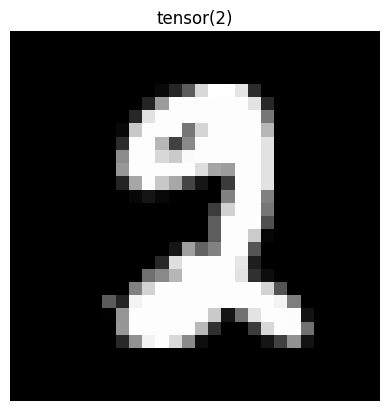

In [ ]:
# Show a sample

#torch.manual_seed(42)
random_idx = torch.randint(0 , len(train_features_batch) , size = [1]).item()
img , label = train_features_batch[random_idx] , train_labels_batch[random_idx]
plt.imshow(img.squeeze() , cmap = "gray")
plt.title(label)
plt.axis(False)
print(f"Image size : {img.shape}")
print(f"Label : {label} , label size : {label.shape}")

## 4. Build a CNN model

In [ ]:
class CNN_Model(nn.Module):

  def __init__(self , input_shape : int , hidden_units : int , output_shape : int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten() ,
        nn.Linear(in_features = hidden_units * 7 * 7 ,
                  out_features = output_shape)
    )


  def forward(self , x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.classifier(x)
    return x


In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
torch.manual_seed(42)
model = CNN_Model(input_shape = 1 ,
                  hidden_units = 10 ,
                  output_shape = 10)

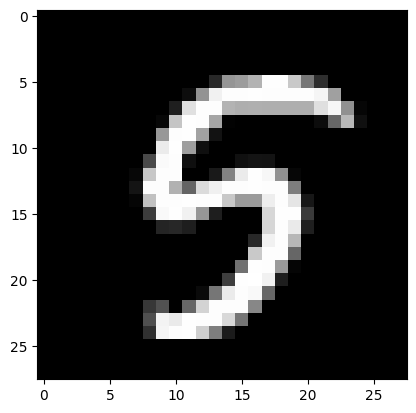

In [ ]:
plt.imshow(image.squeeze() , cmap = "gray")

In [ ]:
rand_image_tensor = torch.randn(size = (1 , 28 , 28))
rand_image_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
model(rand_image_tensor.unsqueeze(0))

tensor([[ 0.0366, -0.0940,  0.0686, -0.0485,  0.0068,  0.0290,  0.0132,  0.0084,
         -0.0030, -0.0185]], grad_fn=<AddmmBackward0>)

**Create a loss function and optimizer**

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model.parameters() ,
                            lr = 0.1)

**Accuracy Function**

In [ ]:
def accuracy_fn(y_true, y_pred):

    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

**Training Step**

In [ ]:
def train_step(model : torch.nn.Module ,
               data_loader : torch.utils.data.DataLoader ,
               loss_fn : torch.nn.Module ,
               optimizer : torch.optim.Optimizer ,
               accuracy_fn):
  """Performs a training with model trying to learn on data_loader."""
  train_loss , train_acc = 0 , 0

  # Put model into training mode
  model.train()


  # Add a loop to loop through the training batches
  for batch , (X , y) in enumerate(data_loader):
    # Put data on target device
    X , y = X , y

    # 1. Forward pass (outputs the raw logits from the model)
    y_pred = model(X)

    # 2. Calculate loss and accuracy (per batch)
    batch_loss = loss_fn(y_pred , y)
    train_loss += batch_loss # accumulate train loss
    train_acc += accuracy_fn(y_true = y ,
                             y_pred = y_pred.argmax(dim = 1)) # go from logits -> prediction labels

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward
    batch_loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Print out what's happenning
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset)} samples.")

  # Divide total train loss and acc. by length of train dataloader
  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss : {train_loss:.5f} | Train acc: {train_acc:.2f}%")

**Testing Loop**

In [ ]:
def test_step(model : torch.nn.Module ,
              data_loader : torch.utils.data.DataLoader ,
              loss_fn : torch.nn.Module ,
              accuracy_fn):


  test_loss , test_acc = 0 , 0

  # Put the model in eval mode
  model.eval()

  # Turn on inference mode context manager
  with torch.inference_mode():
    for X , y in data_loader:
      # Send the data to the target device
      x , y = X , y

      # 1. Forward pass
      test_pred = model(X)

      # 2. Calculate the loss/acc
      test_loss += loss_fn(test_pred , y)
      test_acc += accuracy_fn(y_true = y ,
                              y_pred = test_pred.argmax(dim = 1)) # go from logits -> prediction labels

    # Adjust metrics and print out
    test_loss /= len(data_loader)
    test_acc /= len(data_loader)
    print(f"Test loss : {test_loss:.5f} | Test acc.: {test_acc:.2f}%\n")

**Training time**

In [ ]:
def print_train_time(start, end, device=None):

    total_time = end - start
    print(f"\nTrain time on {device}: {total_time:.3f} seconds")
    return total_time

**Training and Testing the model**

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.38425 | Train acc: 87.03%
Test loss : 0.09275 | Test acc.: 97.05%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.08726 | Train acc: 97.22%
Test loss : 0.08772 | Test acc.: 97.30%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.06398 | Train acc: 97.93%
Test loss : 0.08489 | Test acc.: 97.46%


Train time on None: 98.820 seconds


# 5. Making predictions

In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module ,
               data_loader: torch.utils.data.DataLoader ,
               loss_fn: torch.nn.Module ,
               accuracy_fn ,
               device = "cpu"):
  """Returns a dictionary containing the results of model predicting on data_loader."""

  loss , acc = 0 , 0
  model.eval()

  with torch.inference_mode():
    for X , y in data_loader:
      # make predictions
      y_pred = model(X)

      # Accumulate the loss and acc. values per batch
      loss += loss_fn(y_pred , y)
      acc += accuracy_fn(y_true = y ,
                         y_pred = y_pred.argmax(dim = 1))

    # Scale loss and acc. to find the average loss/acc. per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name" : model.__class__.__name__ , # only works when model was created with class
          "model_loss" : loss.item() ,
          "model_acc" : acc}

# Calculate model_0 results on test dataset
model_results = eval_model(model ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model',
 'model_loss': 0.08488788455724716,
 'model_acc': 97.45722433460077}

Let's increase the accuracy of a model by fine-tuning some hyperparameters

Let's increase some hidden units

In [ ]:
torch.manual_seed(42)
model_2 = CNN_Model(input_shape = 1 ,
                  hidden_units = 15 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_2.parameters() ,
                            lr = 0.1)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_2 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_2,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.42055 | Train acc: 85.99%
Test loss : 0.09604 | Test acc.: 97.01%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.08867 | Train acc: 97.24%
Test loss : 0.08272 | Test acc.: 97.49%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.06453 | Train acc: 98.04%
Test loss : 0.07519 | Test acc.: 97.68%


Train time on None: 107.880 seconds


In [ ]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module ,
               data_loader: torch.utils.data.DataLoader ,
               loss_fn: torch.nn.Module ,
               accuracy_fn ,
               device = "cpu"):
  """Returns a dictionary containing the results of model predicting on data_loader."""

  loss , acc = 0 , 0
  model.eval()

  with torch.inference_mode():
    for X , y in data_loader:
      # make predictions
      y_pred = model(X)

      # Accumulate the loss and acc. values per batch
      loss += loss_fn(y_pred , y)
      acc += accuracy_fn(y_true = y ,
                         y_pred = y_pred.argmax(dim = 1))

    # Scale loss and acc. to find the average loss/acc. per batch
    loss /= len(data_loader)
    acc /= len(data_loader)

  return {"model_name" : model.__class__.__name__ , # only works when model was created with class
          "model_loss" : loss.item() ,
          "model_acc" : acc}

# Calculate model_0 results on test dataset
model_results = eval_model(model_2 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model',
 'model_loss': 0.0751909613609314,
 'model_acc': 97.68298479087453}

Let's increase the layer

In [ ]:
class CNN_Model_2(nn.Module):

  def __init__(self , input_shape : int , hidden_units : int , output_shape : int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.Conv2d(in_channels = hidden_units ,
                  out_channels = hidden_units ,
                  kernel_size = 3 ,
                  stride = 1 ,
                  padding = 1) ,
        nn.ReLU() ,
        nn.MaxPool2d(kernel_size = 2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten() ,
        nn.Linear(in_features = hidden_units * 3 * 3, # Changed from 7*7*7 to 3*3
                  out_features = output_shape)
    )


  def forward(self , x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.conv_block_3(x)
    x = self.classifier(x)
    return x

In [ ]:
torch.manual_seed(42)
model_3 = CNN_Model_2(input_shape = 1 ,
                  hidden_units = 15 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_3.parameters() ,
                            lr = 0.1)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_3 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_3,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 1.71371 | Train acc: 35.85%
Test loss : 0.25862 | Test acc.: 91.69%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.13302 | Train acc: 95.89%
Test loss : 0.07883 | Test acc.: 97.37%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.07780 | Train acc: 97.65%
Test loss : 0.09711 | Test acc.: 96.91%


Train time on None: 116.706 seconds


In [ ]:
model_results = eval_model(model_3 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model_2',
 'model_loss': 0.09710986167192459,
 'model_acc': 96.9106463878327}

Let's increase the hidden units for the CNN_Model_2 about 50

In [ ]:
torch.manual_seed(42)
model_4 = CNN_Model_2(input_shape = 1 ,
                  hidden_units = 32 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_4.parameters() ,
                            lr = 0.1)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_4 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_4,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 1.94184 | Train acc: 26.92%
Test loss : 0.30295 | Test acc.: 89.96%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.15479 | Train acc: 95.15%
Test loss : 0.08317 | Test acc.: 97.35%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.07885 | Train acc: 97.63%
Test loss : 0.08855 | Test acc.: 97.02%

Epoch : 3
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.05458 | Train acc: 98.32%
Test loss : 0.06350 | Test acc.: 97.96%

Epoch : 4
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.04531 | Train acc: 98.55%
Test loss : 0.05057 | Test acc.: 98.36%

Epoch : 5
-------
Looked 

In [ ]:
model_results = eval_model(model_4 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model_2',
 'model_loss': 0.043192289769649506,
 'model_acc': 98.58602661596959}

Now, let's change the Optimizer to "Adam"

In [ ]:
torch.manual_seed(42)
model_5 = CNN_Model_2(input_shape = 1 ,
                  hidden_units = 32 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_5.parameters() ,
                            lr = 0.001)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_5 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_5,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.25579 | Train acc: 91.60%
Test loss : 0.07379 | Test acc.: 97.78%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.06908 | Train acc: 97.89%
Test loss : 0.06192 | Test acc.: 98.02%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.04720 | Train acc: 98.51%
Test loss : 0.05316 | Test acc.: 98.40%

Epoch : 3
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.03703 | Train acc: 98.80%
Test loss : 0.04978 | Test acc.: 98.49%

Epoch : 4
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.03160 | Train acc: 98.98%
Test loss : 0.04126 | Test acc.: 98.67%

Epoch : 5
-------
Looked 

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = (y_pred == y_true).sum().item()
    acc = correct / len(y_true) * 100
    return acc

In [ ]:
model_results = eval_model(model_5 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model_2',
 'model_loss': 0.0549018457531929,
 'model_acc': 98.56226235741445}

Use same optimizer , with different learning rate

In [ ]:
torch.manual_seed(42)
model_6 = CNN_Model_2(input_shape = 1 ,
                  hidden_units = 32 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_6.parameters() ,
                            lr = 0.01)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_6 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_6,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 2.30254 | Train acc: 10.96%
Test loss : 2.30270 | Test acc.: 10.98%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 2.30260 | Train acc: 10.90%
Test loss : 2.30252 | Test acc.: 10.98%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 2.30237 | Train acc: 11.06%
Test loss : 2.30447 | Test acc.: 10.54%

Epoch : 3
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 2.30292 | Train acc: 10.82%
Test loss : 2.30162 | Test acc.: 10.98%

Epoch : 4
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 2.30246 | Train acc: 10.85%
Test loss : 2.30257 | Test acc.: 10.98%

Epoch : 5
-------
Looked 

In [ ]:
model_results = eval_model(model_6 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model_2',
 'model_loss': 2.3029050827026367,
 'model_acc': 10.539448669201521}

test the model with two layers

In [ ]:
torch.manual_seed(42)
model_7 = CNN_Model(input_shape = 1 ,
                  hidden_units = 32 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_7.parameters() ,
                            lr = 0.001)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_7 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_7,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.20411 | Train acc: 93.64%
Test loss : 0.07610 | Test acc.: 97.87%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.05722 | Train acc: 98.26%
Test loss : 0.05505 | Test acc.: 98.27%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.04070 | Train acc: 98.67%
Test loss : 0.05142 | Test acc.: 98.50%

Epoch : 3
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.03260 | Train acc: 98.97%
Test loss : 0.04652 | Test acc.: 98.54%

Epoch : 4
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.02485 | Train acc: 99.24%
Test loss : 0.05122 | Test acc.: 98.61%

Epoch : 5
-------
Looked 

In [ ]:
model_results = eval_model(model_7 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model',
 'model_loss': 0.0627283975481987,
 'model_acc': 98.51473384030419}

Let's increase the no. of hidden units in two-layered CNN model

In [ ]:
torch.manual_seed(42)
model_8 = CNN_Model(input_shape = 1 ,
                  hidden_units = 64 ,
                  output_shape = 10)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_8.parameters() ,
                            lr = 0.001)

In [ ]:
from tqdm.auto import tqdm

torch.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model = timer()

# Train and test model
epochs = 10
for epoch in tqdm(range(epochs)):
  print(f"Epoch : {epoch}\n-------")
  train_step(model = model_8 ,
             data_loader = train_dataloader ,
             loss_fn = loss_fn ,
             optimizer = optimizer ,
             accuracy_fn = accuracy_fn)
  test_step(model = model_8,
            data_loader = test_dataloader ,
            loss_fn = loss_fn ,
            accuracy_fn = accuracy_fn)

train_time_end_model = timer()
total_train_time_model = print_train_time(start = train_time_start_model,
                                            end = train_time_end_model)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch : 0
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.15932 | Train acc: 94.98%
Test loss : 0.06199 | Test acc.: 98.00%

Epoch : 1
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.04893 | Train acc: 98.55%
Test loss : 0.04941 | Test acc.: 98.51%

Epoch : 2
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.03361 | Train acc: 98.95%
Test loss : 0.04907 | Test acc.: 98.51%

Epoch : 3
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.02533 | Train acc: 99.16%
Test loss : 0.05481 | Test acc.: 98.31%

Epoch : 4
-------
Looked at 0 / 33600 samples.
Looked at 12800 / 33600 samples.
Looked at 25600 / 33600 samples.
Train loss : 0.02078 | Train acc: 99.34%
Test loss : 0.04661 | Test acc.: 98.66%

Epoch : 5
-------
Looked 

In [ ]:
model_results = eval_model(model_8 ,
                             data_loader = test_dataloader ,
                             loss_fn = loss_fn ,
                             accuracy_fn = accuracy_fn)

model_results

{'model_name': 'CNN_Model',
 'model_loss': 0.0633714571595192,
 'model_acc': 98.39591254752851}

Let's save all the trained model

In [ ]:
torch.save(model.state_dict(), "mnist_cnn_model_1.pth")
torch.save(model_2.state_dict(), "mnist_cnn_model_2.pth")
torch.save(model_3.state_dict(), "mnist_cnn_model_3.pth")
torch.save(model_4.state_dict(), "mnist_cnn_model_4.pth")
torch.save(model_5.state_dict(), "mnist_cnn_model_5.pth")
torch.save(model_6.state_dict(), "mnist_cnn_model_6.pth")
torch.save(model_7.state_dict(), "mnist_cnn_model_7.pth")
torch.save(model_8.state_dict(), "mnist_cnn_model_8.pth")